# HumanLens AI — Emotion Analysis

## Objective

This notebook develops the emotion-analysis component of the HumanLens
Text Layer.

The objective is to identify emotional signals expressed in text and
convert them into structured features that can later be provided to the
HumanLens Multimodal Fusion Engine.

## Dataset

GoEmotions is used as the primary emotion-analysis dataset.

The dataset contains Reddit comments annotated with 27 emotion
categories plus Neutral.

## HumanLens Emotion Representation

The emotion layer will provide:

- Predicted emotion
- Emotion confidence
- Emotion intensity

These outputs are treated as communication-level signals.

They must not be interpreted as proof of a user's psychological state,
personality, mental-health condition, or diagnosis.

## Research Questions

1. Which emotions are most common in the dataset?
2. How accurately can emotions be predicted from text?
3. Which emotions are difficult to distinguish?
4. How does emotion prediction behave for short text?
5. Can emotion information provide a useful additional signal alongside
   toxicity and aggression?

## Multilingual Limitation

GoEmotions primarily provides English-language emotion data.

Therefore, this notebook establishes the English emotion foundation.

Multilingual emotion analysis will be treated separately rather than
assuming that an English emotion model transfers equally well to Hindi,
Hinglish, or other languages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
emotion_dataset = load_dataset("google-research-datasets/go_emotions")

print(emotion_dataset)

'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'huggingface.co'. (_ssl.c:1032)' thrown while requesting HEAD https://huggingface.co/datasets/google-research-datasets/go_emotions/resolve/add492243ff905527e67aeb8b80c082af02207c3/go_emotions.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since google-research-datasets/go_emotions couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'simplified' at C:\Users\shash\.cache\huggingface\datasets\google-research-datasets___go_emotions\simplified\0.0.0\add492243ff905527e67aeb8b80c082af02207c3 (last modified on Tue Sep  1 07:25:17 2026).


DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [3]:
print("Available splits:")
print(emotion_dataset)

print("\nFeatures:")
print(emotion_dataset["train"].features)

Available splits:
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Features:
{'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}


In [4]:
for split in emotion_dataset:
    print(
        f"{split:12} : "
        f"{len(emotion_dataset[split]):,} samples"
    )

train        : 43,410 samples
validation   : 5,426 samples
test         : 5,427 samples


In [5]:
emotion_sample = (
    emotion_dataset["train"]
    .select(range(10))
    .to_pandas()
)

emotion_sample

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj
5,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,[26],edvnz26
6,Yes I heard abt the f bombs! That has to be wh...,[15],ee3b6wu
7,We need more boards and to create a bit more s...,"[8, 20]",ef4qmod
8,Damn youtube and outrage drama is super lucrat...,[0],ed8wbdn
9,It might be linked to the trust factor of your...,[27],eczgv1o


In [6]:
features = emotion_dataset["train"].features

print(features)

{'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}


In [7]:
emotion_names = features["labels"].feature.names

print("Number of emotion categories:", len(emotion_names))

for i, emotion in enumerate(emotion_names):
    print(i, ":", emotion)

Number of emotion categories: 28
0 : admiration
1 : amusement
2 : anger
3 : annoyance
4 : approval
5 : caring
6 : confusion
7 : curiosity
8 : desire
9 : disappointment
10 : disapproval
11 : disgust
12 : embarrassment
13 : excitement
14 : fear
15 : gratitude
16 : grief
17 : joy
18 : love
19 : nervousness
20 : optimism
21 : pride
22 : realization
23 : relief
24 : remorse
25 : sadness
26 : surprise
27 : neutral


In [8]:
emotion_train_df = emotion_dataset["train"].to_pandas()

print("Shape:", emotion_train_df.shape)

emotion_train_df.head()

Shape: (43410, 3)


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [9]:
def convert_emotion_ids(label_ids):
    return [
        emotion_names[int(label_id)]
        for label_id in label_ids
    ]


emotion_train_df["emotion_names"] = (
    emotion_train_df["labels"]
    .apply(convert_emotion_ids)
)

emotion_train_df[
    ["text", "emotion_names"]
].head(20)

,text,emotion_names
0,My favourite food is anything I didn't have to...,[neutral]
1,"Now if he does off himself, everyone will thin...",[neutral]
2,WHY THE FUCK IS BAYLESS ISOING,[anger]
3,To make her feel threatened,[fear]
4,Dirty Southern Wankers,[annoyance]
5,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,[surprise]
6,Yes I heard abt the f bombs! That has to be wh...,[gratitude]
7,We need more boards and to create a bit more s...,"[desire, optimism]"
8,Damn youtube and outrage drama is super lucrat...,[admiration]
9,It might be linked to the trust factor of your...,[neutral]


In [10]:
from collections import Counter

emotion_counter = Counter()

for emotions in emotion_train_df["emotion_names"]:
    emotion_counter.update(emotions)

emotion_counts = pd.Series(
    emotion_counter
).sort_values(
    ascending=False
)

emotion_counts

neutral           14219
admiration         4130
approval           2939
gratitude          2662
annoyance          2470
amusement          2328
curiosity          2191
love               2086
disapproval        2022
optimism           1581
anger              1567
joy                1452
confusion          1368
sadness            1326
disappointment     1269
realization        1110
caring             1087
surprise           1060
excitement          853
disgust             793
desire              641
fear                596
remorse             545
embarrassment       303
nervousness         164
relief              153
pride               111
grief                77
dtype: int64

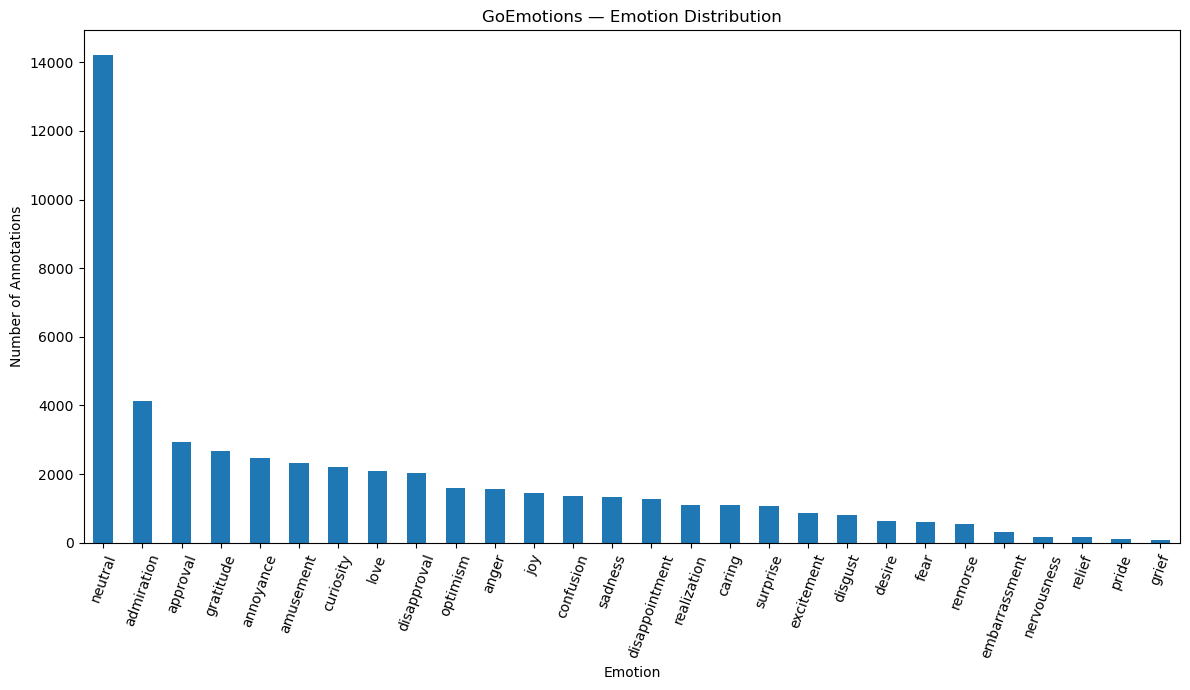

In [11]:
plt.figure(figsize=(12, 7))

emotion_counts.plot(kind="bar")

plt.title("GoEmotions — Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Annotations")
plt.xticks(rotation=70)

plt.tight_layout()
plt.show()

In [12]:
print("Top 10 emotions:")
print("=" * 40)

print(emotion_counts.head(10))

Top 10 emotions:
neutral        14219
admiration      4130
approval        2939
gratitude       2662
annoyance       2470
amusement       2328
curiosity       2191
love            2086
disapproval     2022
optimism        1581
dtype: int64


In [13]:
emotion_train_df["primary_emotion"] = (
    emotion_train_df["emotion_names"]
    .apply(lambda x: x[0] if len(x) > 0 else "neutral")
)

print(
    emotion_train_df["primary_emotion"]
    .value_counts()
)

primary_emotion
neutral           12823
admiration         4130
approval           2596
amusement          2244
annoyance          2138
gratitude          2096
curiosity          1772
disapproval        1651
anger              1547
love               1533
confusion          1268
disappointment     1028
joy                1013
optimism            974
caring              966
sadness             874
surprise            751
excitement          700
realization         698
disgust             580
desire              543
fear                510
remorse             404
embarrassment       248
nervousness         105
relief               96
grief                65
pride                57
Name: count, dtype: int64


In [14]:
EMOTION_EVAL_SIZE = 5000
RANDOM_SEED = 42

emotion_eval_df = (
    emotion_train_df
    .sample(
        n=EMOTION_EVAL_SIZE,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)

print(
    "Emotion evaluation samples:",
    len(emotion_eval_df)
)

Emotion evaluation samples: 5000


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [16]:
X_text = emotion_eval_df["text"].fillna("")
y_emotion = emotion_eval_df["primary_emotion"]

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_tfidf = vectorizer.fit_transform(X_text)

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (5000, 8840)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y_emotion,
    test_size=0.20,
    random_state=42,
    stratify=y_emotion
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4000
Testing samples: 1000


In [18]:
emotion_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

emotion_model.fit(
    X_train,
    y_train
)

print("Emotion baseline trained successfully.")

Emotion baseline trained successfully.


In [19]:
emotion_predictions = emotion_model.predict(X_test)

print("Predictions generated.")

Predictions generated.


In [20]:
emotion_accuracy = accuracy_score(
    y_test,
    emotion_predictions
)

emotion_precision = precision_score(
    y_test,
    emotion_predictions,
    average="weighted",
    zero_division=0
)

emotion_recall = recall_score(
    y_test,
    emotion_predictions,
    average="weighted",
    zero_division=0
)

emotion_f1 = f1_score(
    y_test,
    emotion_predictions,
    average="weighted",
    zero_division=0
)

print("HumanLens Emotion Baseline")
print("=" * 50)

print(f"Accuracy  : {emotion_accuracy:.4f}")
print(f"Precision : {emotion_precision:.4f}")
print(f"Recall    : {emotion_recall:.4f}")
print(f"F1-score  : {emotion_f1:.4f}")

HumanLens Emotion Baseline
Accuracy  : 0.3040
Precision : 0.3974
Recall    : 0.3040
F1-score  : 0.2943


In [21]:
print(
    classification_report(
        y_test,
        emotion_predictions,
        zero_division=0
    )
)

                precision    recall  f1-score   support

    admiration       0.54      0.38      0.45       103
     amusement       0.56      0.62      0.59        48
         anger       0.31      0.43      0.36        37
     annoyance       0.11      0.11      0.11        46
      approval       0.17      0.16      0.16        58
        caring       0.15      0.36      0.21        22
     confusion       0.17      0.26      0.21        27
     curiosity       0.21      0.30      0.25        43
        desire       0.15      0.15      0.15        13
disappointment       0.16      0.30      0.21        23
   disapproval       0.14      0.26      0.18        34
       disgust       0.19      0.33      0.24        15
 embarrassment       0.20      0.17      0.18         6
    excitement       0.13      0.24      0.17        17
          fear       0.27      0.33      0.30         9
     gratitude       0.73      0.85      0.79        52
         grief       0.00      0.00      0.00  

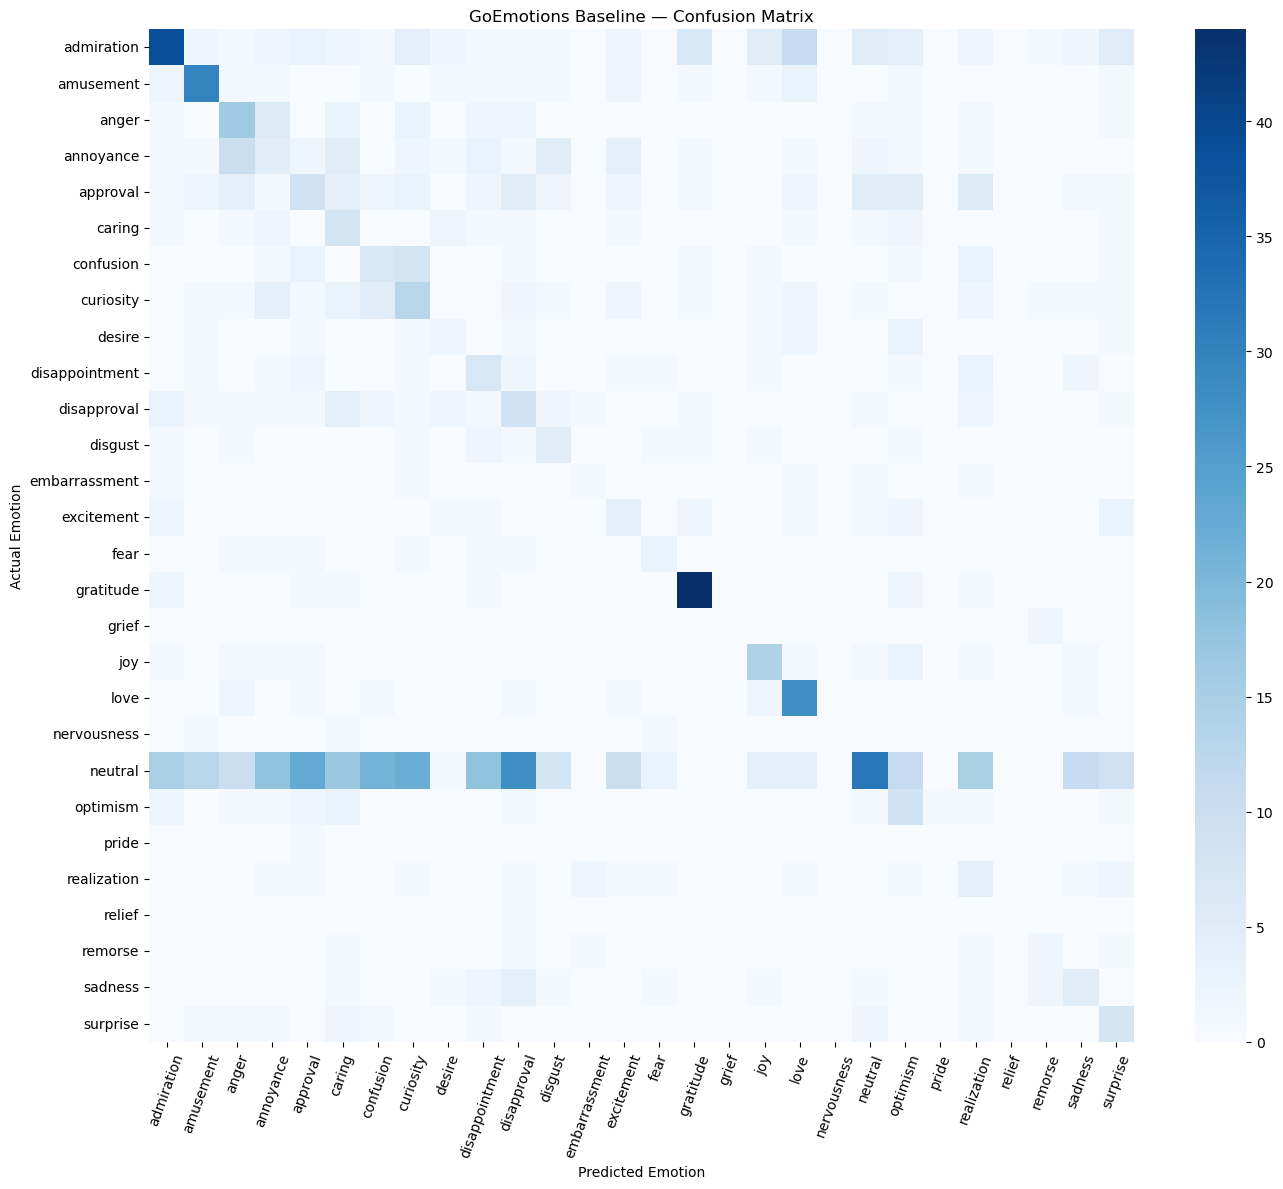

In [22]:
emotion_labels = sorted(
    y_test.unique()
)

cm = confusion_matrix(
    y_test,
    emotion_predictions,
    labels=emotion_labels
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=emotion_labels,
    yticklabels=emotion_labels
)

plt.title("GoEmotions Baseline — Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.xticks(rotation=70)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [23]:
emotion_probabilities = emotion_model.predict_proba(X_test)

emotion_confidence = (
    emotion_probabilities.max(axis=1)
)

emotion_results = pd.DataFrame({
    "text": emotion_eval_df.loc[
        y_test.index,
        "text"
    ].values,
    "actual_emotion": y_test.values,
    "predicted_emotion": emotion_predictions,
    "emotion_confidence": emotion_confidence
})

emotion_results.head(20)

,text,actual_emotion,predicted_emotion,emotion_confidence
0,I’ll never understand people who freak out at ...,approval,anger,0.066089
1,"I was kinda just silent the whole time, we hav...",neutral,realization,0.072327
2,yes!!! Once I realized my body wasn't wanting ...,realization,love,0.169542
3,Good puppy!,admiration,admiration,0.319698
4,Amazing!! Congrats!,admiration,admiration,0.195092
5,Very sorry for your loss.,grief,remorse,0.212240
6,Thank you SO much! This is so genuine and so h...,admiration,gratitude,0.495690
7,I'm jealous. I'm in California,neutral,neutral,0.058750
8,Next commercial break mute your TV and watch t...,neutral,caring,0.060854
9,"yeah, it's basically Hillsong with sugary shak...",approval,approval,0.093651


In [24]:
humanlens_emotion_tests = [
    "I am extremely happy today!",
    "I am so angry with what happened.",
    "I am really scared about tomorrow.",
    "I feel very sad right now.",
    "Thank you so much for helping me.",
    "What is happening? I don't understand.",
    "I am really excited about this!",
    "I am the fucking stupidest person alive ",
    "Teri maa ki chut me moot dunga",
    "I completely disagree with you."
]

test_matrix = vectorizer.transform(
    humanlens_emotion_tests
)

test_predictions = emotion_model.predict(
    test_matrix
)

test_probabilities = emotion_model.predict_proba(
    test_matrix
)

test_confidence = test_probabilities.max(axis=1)

emotion_test_results = pd.DataFrame({
    "text": humanlens_emotion_tests,
    "predicted_emotion": test_predictions,
    "confidence": test_confidence
})

emotion_test_results

,text,predicted_emotion,confidence
0,I am extremely happy today!,joy,0.233558
1,I am so angry with what happened.,curiosity,0.091443
2,I am really scared about tomorrow.,fear,0.217694
3,I feel very sad right now.,sadness,0.345854
4,Thank you so much for helping me.,gratitude,0.690410
5,What is happening? I don't understand.,confusion,0.118428
6,I am really excited about this!,excitement,0.122806
7,I am the fucking stupidest person alive,anger,0.146934
8,Teri maa ki chut me moot dunga,fear,0.151045
9,I completely disagree with you.,disapproval,0.085452


In [25]:
from pathlib import Path

In [26]:
results_dir = Path("../results")

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

emotion_results_path = (
    results_dir /
    "emotion_baseline_results.csv"
)

emotion_results.to_csv(
    emotion_results_path,
    index=False,
    encoding="utf-8-sig"
)

print("Emotion results saved:")
print(emotion_results_path)

Emotion results saved:
..\results\emotion_baseline_results.csv


In [27]:
import joblib

model_dir = Path("../models")
model_dir.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    emotion_model,
    model_dir / "emotion_logistic_regression.pkl"
)

joblib.dump(
    vectorizer,
    model_dir / "emotion_tfidf_vectorizer.pkl"
)

print("Emotion model and vectorizer saved successfully.")

Emotion model and vectorizer saved successfully.


# Emotion Analysis — Research Findings

## Dataset

GoEmotions was used as the primary English-language emotion dataset.

The dataset provides fine-grained emotion annotations covering
27 emotion categories plus Neutral.

## Baseline

A TF-IDF + Logistic Regression model was implemented as the initial
emotion-classification baseline.

## Evaluation

The model was evaluated using:

- Accuracy
- Precision
- Recall
- Weighted F1-score
- Classification report
- Confusion matrix

## Emotion Confidence

The maximum predicted class probability was retained as an initial
emotion-confidence feature.

This value represents model confidence and must not be interpreted
as a direct measurement of the user's psychological emotional state.

## Limitations

The first baseline simplifies the multi-label emotion annotations
into a primary emotion.

Emotion classification from text is inherently uncertain and
context-dependent.

The model is also primarily English-oriented at this stage.

Therefore, these results cannot be assumed to represent equivalent
performance for Hindi, Hinglish, or other languages.

## HumanLens Integration

The emotion layer will provide:

- Predicted emotion
- Emotion confidence

These signals will later be combined with:

- Toxicity
- Aggression
- Voice features
- Facial-expression features
- Behavioral context

within the HumanLens Multimodal Fusion Engine.

## Next Stage

The next research component is the Behavior Lens, which will investigate
longitudinal behavioral features such as sleep, stress, academic pressure,
social interaction, mood, physical activity, and digital exposure.